In [10]:
from src.adasecant import Adasecant
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
from torchvision.transforms import ToTensor
from torch.optim.optimizer import Optimizer
import matplotlib.pyplot as plt
import time
import torch.nn.functional as F
from torchvision.models import ResNet18_Weights
import numpy as np

# First functionality test

In [2]:
# 1. Device configuration
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

# 2. Downloading data
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

# 3. Creating DataLoaders
batch_size = 64
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

# 4. Model definition
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten() 
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)

# 5. Loss function and Optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adasecant(model.parameters())

# 6. Training loop (MODIFIED)
def train(dataloader, model, loss_fn, optimizer):
    model.train() 
    train_loss = 0
    
    # Iterate silently through all batches in the epoch
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        train_loss += loss.item()
        
    # Optional: calculate the average training loss for the current epoch
    train_loss /= len(dataloader)
    print(f"Training completed. Average training loss: {train_loss:>8f}")

# 7. Evaluation loop (Testing)
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval() 
    test_loss, correct = 0, 0
    
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
            
    test_loss /= num_batches
    correct /= size
    print(f"Test set results: Accuracy: {(100*correct):>0.1f}%, Average test loss: {test_loss:>8f}\n")

# 8. Running the entire process
epochs = 5 
for t in range(epochs):
    print(f"Epoch {t+1}")
    print("-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done! Training completed.")

Using device: cuda
Epoch 1
-------------------------------
Training completed. Average training loss: 0.497815
Test set results: Accuracy: 85.0%, Average test loss: 0.420191

Epoch 2
-------------------------------
Training completed. Average training loss: 0.365079
Test set results: Accuracy: 86.6%, Average test loss: 0.374614

Epoch 3
-------------------------------
Training completed. Average training loss: 0.320423
Test set results: Accuracy: 87.4%, Average test loss: 0.352946

Epoch 4
-------------------------------
Training completed. Average training loss: 0.293545
Test set results: Accuracy: 87.7%, Average test loss: 0.343104

Epoch 5
-------------------------------
Training completed. Average training loss: 0.272824
Test set results: Accuracy: 87.9%, Average test loss: 0.334482

Done! Training completed.


# Comparison with ADAM (network: CNN, dataset: CIFAR)

Device: cuda

--- Starting training using optimizer: Adam ---
Epoch 1/50 | Loss (Train): 1.4005 | Accuracy (Test): 57.7%
Epoch 2/50 | Loss (Train): 1.0661 | Accuracy (Test): 63.7%
Epoch 3/50 | Loss (Train): 0.9099 | Accuracy (Test): 65.6%
Epoch 4/50 | Loss (Train): 0.8008 | Accuracy (Test): 68.1%
Epoch 5/50 | Loss (Train): 0.6984 | Accuracy (Test): 69.7%
Epoch 6/50 | Loss (Train): 0.6095 | Accuracy (Test): 69.7%
Epoch 7/50 | Loss (Train): 0.5235 | Accuracy (Test): 70.3%
Epoch 8/50 | Loss (Train): 0.4374 | Accuracy (Test): 70.2%
Epoch 9/50 | Loss (Train): 0.3632 | Accuracy (Test): 69.5%
Epoch 10/50 | Loss (Train): 0.2960 | Accuracy (Test): 70.3%
Epoch 11/50 | Loss (Train): 0.2299 | Accuracy (Test): 70.3%
Epoch 12/50 | Loss (Train): 0.1838 | Accuracy (Test): 69.3%
Epoch 13/50 | Loss (Train): 0.1450 | Accuracy (Test): 69.1%
Epoch 14/50 | Loss (Train): 0.1174 | Accuracy (Test): 69.2%
Epoch 15/50 | Loss (Train): 0.1059 | Accuracy (Test): 69.2%
Epoch 16/50 | Loss (Train): 0.0879 | Accuracy (

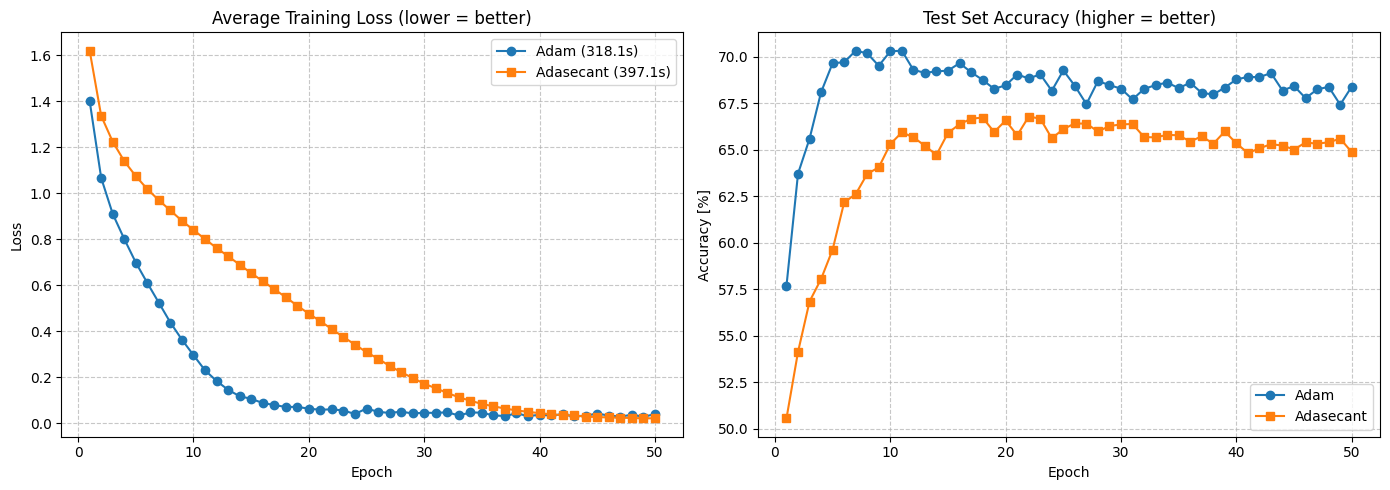

In [3]:
# ==========================================
# 2. NETWORK DEFINITION (Classic small CNN)
# ==========================================
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 3 channels (RGB), 16 filters
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # Image 32x32 -> 16x16
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # Image 16x16 -> 8x8
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, 10) # 10 output classes
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# ==========================================
# 3. TRAINING FUNCTION AND RESULTS LOGGING
# ==========================================
def run_experiment(optimizer_name, device, train_loader, test_loader, epochs=5):
    print(f"\n--- Starting training using optimizer: {optimizer_name} ---")
    
    # Initialize a new network every time so they start from a similar baseline!
    torch.manual_seed(42) # For reproducible results
    model = SimpleCNN().to(device)
    loss_fn = nn.CrossEntropyLoss()
    
    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    else:
        # Here comes our algorithm
        optimizer = Adasecant(model.parameters()) 

    history = {'train_loss': [], 'test_acc': [], 'time': 0}
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for batch_idx, (X, y) in enumerate(train_loader):
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            pred = model(X)
            loss = loss_fn(pred, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        avg_train_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)
        
        # Evaluation after each epoch
        model.eval()
        correct = 0
        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                pred = model(X)
                correct += (pred.argmax(1) == y).type(torch.float).sum().item()
        
        test_acc = correct / len(test_loader.dataset)
        history['test_acc'].append(test_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | Loss (Train): {avg_train_loss:.4f} | Accuracy (Test): {test_acc*100:.1f}%")

    history['time'] = time.time() - start_time
    print(f"Completed in {history['time']:.2f} seconds.")
    return history

# ==========================================
# 4. MAIN PROGRAM LOOP (Visualization)
# ==========================================
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
    print(f"Device: {device}")

    # Transformations: CIFAR-10 are 32x32 color images. We normalize them to the range [-1, 1]
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    print("Downloading CIFAR-10 dataset...")
    train_data = datasets.CIFAR10(root="data", train=True, download=True, transform=transform)
    test_data = datasets.CIFAR10(root="data", train=False, download=True, transform=transform)

    batch_size = 64
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

    # Set the number of epochs (you can increase it to e.g., 10-20 for better results)
    NUM_EPOCHS = 50

    # Run two experiments
    adam_results = run_experiment("Adam", device, train_loader, test_loader, epochs=NUM_EPOCHS)
    adasecant_results = run_experiment("Adasecant", device, train_loader, test_loader, epochs=NUM_EPOCHS)

    # Visualize the results
    epochs_range = range(1, NUM_EPOCHS + 1)

    plt.figure(figsize=(14, 5))

    # Loss Chart
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, adam_results['train_loss'], label=f"Adam ({adam_results['time']:.1f}s)", marker='o')
    plt.plot(epochs_range, adasecant_results['train_loss'], label=f"Adasecant ({adasecant_results['time']:.1f}s)", marker='s')
    plt.title("Average Training Loss (lower = better)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # Accuracy Chart
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, [acc * 100 for acc in adam_results['test_acc']], label="Adam", marker='o', color='tab:blue')
    plt.plot(epochs_range, [acc * 100 for acc in adasecant_results['test_acc']], label="Adasecant", marker='s', color='tab:orange')
    plt.title("Test Set Accuracy (higher = better)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy [%]")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Easy sinusoid problem

Device: cuda

--- Training: Adam ---


/tmp/ipykernel_22972/1975576939.py:12: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  self.X = torch.tensor(self.X, dtype=torch.float32).unsqueeze(-1)


Epoch 1/30 | Loss Train: 0.17601 | Loss Test: 0.04382
Epoch 5/30 | Loss Train: 0.01526 | Loss Test: 0.01597
Epoch 10/30 | Loss Train: 0.01508 | Loss Test: 0.01461
Epoch 15/30 | Loss Train: 0.01394 | Loss Test: 0.01469
Epoch 20/30 | Loss Train: 0.01429 | Loss Test: 0.01529
Epoch 25/30 | Loss Train: 0.01359 | Loss Test: 0.01347
Epoch 30/30 | Loss Train: 0.01301 | Loss Test: 0.01487
Completed in 8.68 s.

--- Training: Adasecant ---
Epoch 1/30 | Loss Train: 0.38438 | Loss Test: 0.03049
Epoch 5/30 | Loss Train: 0.01687 | Loss Test: 0.01646
Epoch 10/30 | Loss Train: 0.01596 | Loss Test: 0.01581
Epoch 15/30 | Loss Train: 0.01584 | Loss Test: 0.01649
Epoch 20/30 | Loss Train: 0.01507 | Loss Test: 0.01616
Epoch 25/30 | Loss Train: 0.01410 | Loss Test: 0.01408
Epoch 30/30 | Loss Train: 0.01352 | Loss Test: 0.01406
Completed in 10.54 s.


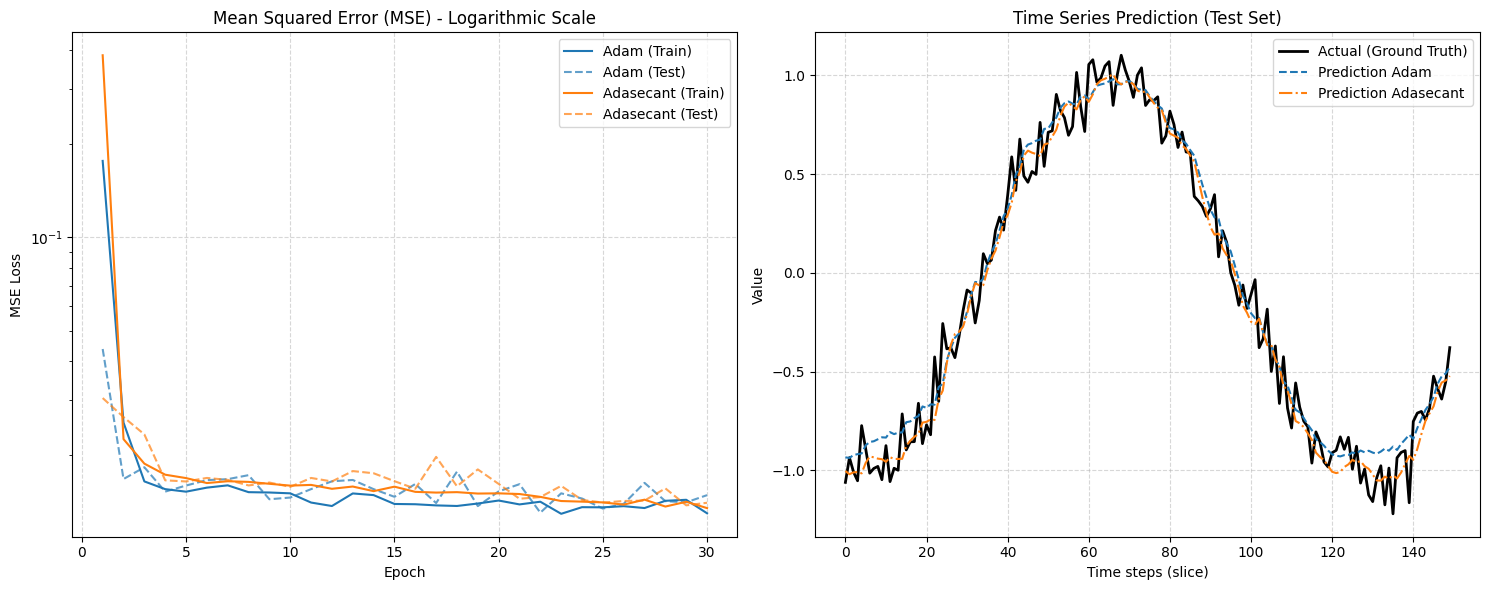

In [6]:
# ==========================================
# 2. DATASET (Noisy Sine Wave)
# ==========================================
class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_length=50):
        self.X = []
        self.y = []
        for i in range(len(data) - seq_length):
            self.X.append(data[i : i + seq_length])
            self.y.append(data[i + seq_length])
            
        self.X = torch.tensor(self.X, dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(self.y, dtype=torch.float32).unsqueeze(-1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ==========================================
# 3. NETWORK DEFINITION (LSTM)
# ==========================================
class LSTMRegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        # lstm expects input: (batch, seq_len, features)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :] # We only take the output from the last time step of the sequence
        out = self.fc(out)
        return out

# ==========================================
# 4. TRAINING LOOP
# ==========================================
def run_regression_experiment(optimizer_name, device, train_loader, test_loader, epochs=30):
    print(f"\n--- Training: {optimizer_name} ---")
    
    torch.manual_seed(42) # Fixed seed so both networks start with the same initial weights
    model = LSTMRegressor().to(device)
    loss_fn = nn.MSELoss() # Mean Squared Error for regression
    
    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    else:
        optimizer = Adasecant(model.parameters())

    history = {'train_loss': [], 'test_loss': [], 'time': 0, 'model': model}
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            pred = model(X)
            loss = loss_fn(pred, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        avg_train_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)
        
        # Evaluation
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                pred = model(X)
                test_loss += loss_fn(pred, y).item()
                
        avg_test_loss = test_loss / len(test_loader)
        history['test_loss'].append(avg_test_loss)
        
        # Log less frequently, e.g., every 5 epochs
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss Train: {avg_train_loss:.5f} | Loss Test: {avg_test_loss:.5f}")

    history['time'] = time.time() - start_time
    print(f"Completed in {history['time']:.2f} s.")
    return history

# ==========================================
# 5. MAIN PROGRAM LOOP AND VISUALIZATION
# ==========================================
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
    print(f"Device: {device}")

    # Generating data
    TOTAL_SAMPLES = 2000
    SEQ_LENGTH = 50
    time_steps = np.linspace(0, 100, TOTAL_SAMPLES)
    # Noisy sine wave
    raw_data = np.sin(time_steps) + np.random.normal(0, 0.1, len(time_steps))

    # Time split (do not shuffle! First 80% is the past, last 20% is the future)
    split_idx = int(0.8 * len(raw_data))
    train_data_raw = raw_data[:split_idx]
    test_data_raw = raw_data[split_idx - SEQ_LENGTH:] # Overlap slightly to have a starting sequence for tests

    train_dataset = TimeSeriesDataset(train_data_raw, seq_length=SEQ_LENGTH)
    test_dataset = TimeSeriesDataset(test_data_raw, seq_length=SEQ_LENGTH)

    # shuffle=True for training helps SGD/Adam stability, test_loader without shuffling for visualization
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

    NUM_EPOCHS = 30 # Optimal for this task

    # Training
    adam_results = run_regression_experiment("Adam", device, train_loader, test_loader, epochs=NUM_EPOCHS)
    adasecant_results = run_regression_experiment("Adasecant", device, train_loader, test_loader, epochs=NUM_EPOCHS)

    # Prepare test data for the chart (extract predictions)
    adam_model = adam_results['model'].eval()
    adasecant_model = adasecant_results['model'].eval()
    
    X_test_all, y_test_all = [], []
    for X, y in test_loader:
        X_test_all.append(X)
        y_test_all.append(y)
    X_test_all = torch.cat(X_test_all).to(device)
    y_test_all = torch.cat(y_test_all).cpu().numpy().flatten()

    with torch.no_grad():
        preds_adam = adam_model(X_test_all).cpu().numpy().flatten()
        preds_adasecant = adasecant_model(X_test_all).cpu().numpy().flatten()

    # --- VISUALIZATION ---
    plt.figure(figsize=(15, 6))

    # Chart 1: Loss (learning) curves
    plt.subplot(1, 2, 1)
    epochs_range = range(1, NUM_EPOCHS + 1)
    plt.plot(epochs_range, adam_results['train_loss'], label="Adam (Train)", linestyle='-', color='tab:blue')
    plt.plot(epochs_range, adam_results['test_loss'], label="Adam (Test)", linestyle='--', color='tab:blue', alpha=0.7)
    plt.plot(epochs_range, adasecant_results['train_loss'], label="Adasecant (Train)", linestyle='-', color='tab:orange')
    plt.plot(epochs_range, adasecant_results['test_loss'], label="Adasecant (Test)", linestyle='--', color='tab:orange', alpha=0.7)
    plt.yscale('log') # Logarithmic scale shows differences better for small MSE errors
    plt.title("Mean Squared Error (MSE) - Logarithmic Scale")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    # Chart 2: Prediction on a slice of the test set (last 150 steps)
    plt.subplot(1, 2, 2)
    view_range = 150 # We only view a slice for readability
    plt.plot(y_test_all[-view_range:], label="Actual (Ground Truth)", color='black', linewidth=2)
    plt.plot(preds_adam[-view_range:], label="Prediction Adam", color='tab:blue', linestyle='--')
    plt.plot(preds_adasecant[-view_range:], label="Prediction Adasecant", color='tab:orange', linestyle='-.')
    plt.title("Time Series Prediction (Test Set)")
    plt.xlabel("Time steps (slice)")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Spatial Patterns Test

Generating Lorenz Attractor...
Using device: cuda

--- Starting training (Lorenz 3D): Adam ---
Epoch  1/40 | Loss Train: 0.932873 | Loss Test: 1.101487
Epoch  5/40 | Loss Train: 0.142219 | Loss Test: 0.116965
Epoch 10/40 | Loss Train: 0.020215 | Loss Test: 0.010728
Epoch 15/40 | Loss Train: 0.004194 | Loss Test: 0.001429
Epoch 20/40 | Loss Train: 0.000869 | Loss Test: 0.000600
Epoch 25/40 | Loss Train: 0.000361 | Loss Test: 0.000405
Epoch 30/40 | Loss Train: 0.000251 | Loss Test: 0.000298
Epoch 35/40 | Loss Train: 0.000154 | Loss Test: 0.000441
Epoch 40/40 | Loss Train: 0.000134 | Loss Test: 0.000186
Completed in 24.62 s.

--- Starting training (Lorenz 3D): Adasecant ---
Epoch  1/40 | Loss Train: 0.367725 | Loss Test: 0.053664
Epoch  5/40 | Loss Train: 0.003630 | Loss Test: 0.002799
Epoch 10/40 | Loss Train: 0.001491 | Loss Test: 0.002063
Epoch 15/40 | Loss Train: 0.001093 | Loss Test: 0.000762
Epoch 20/40 | Loss Train: 0.000917 | Loss Test: 0.001268
Epoch 25/40 | Loss Train: 0.000783 

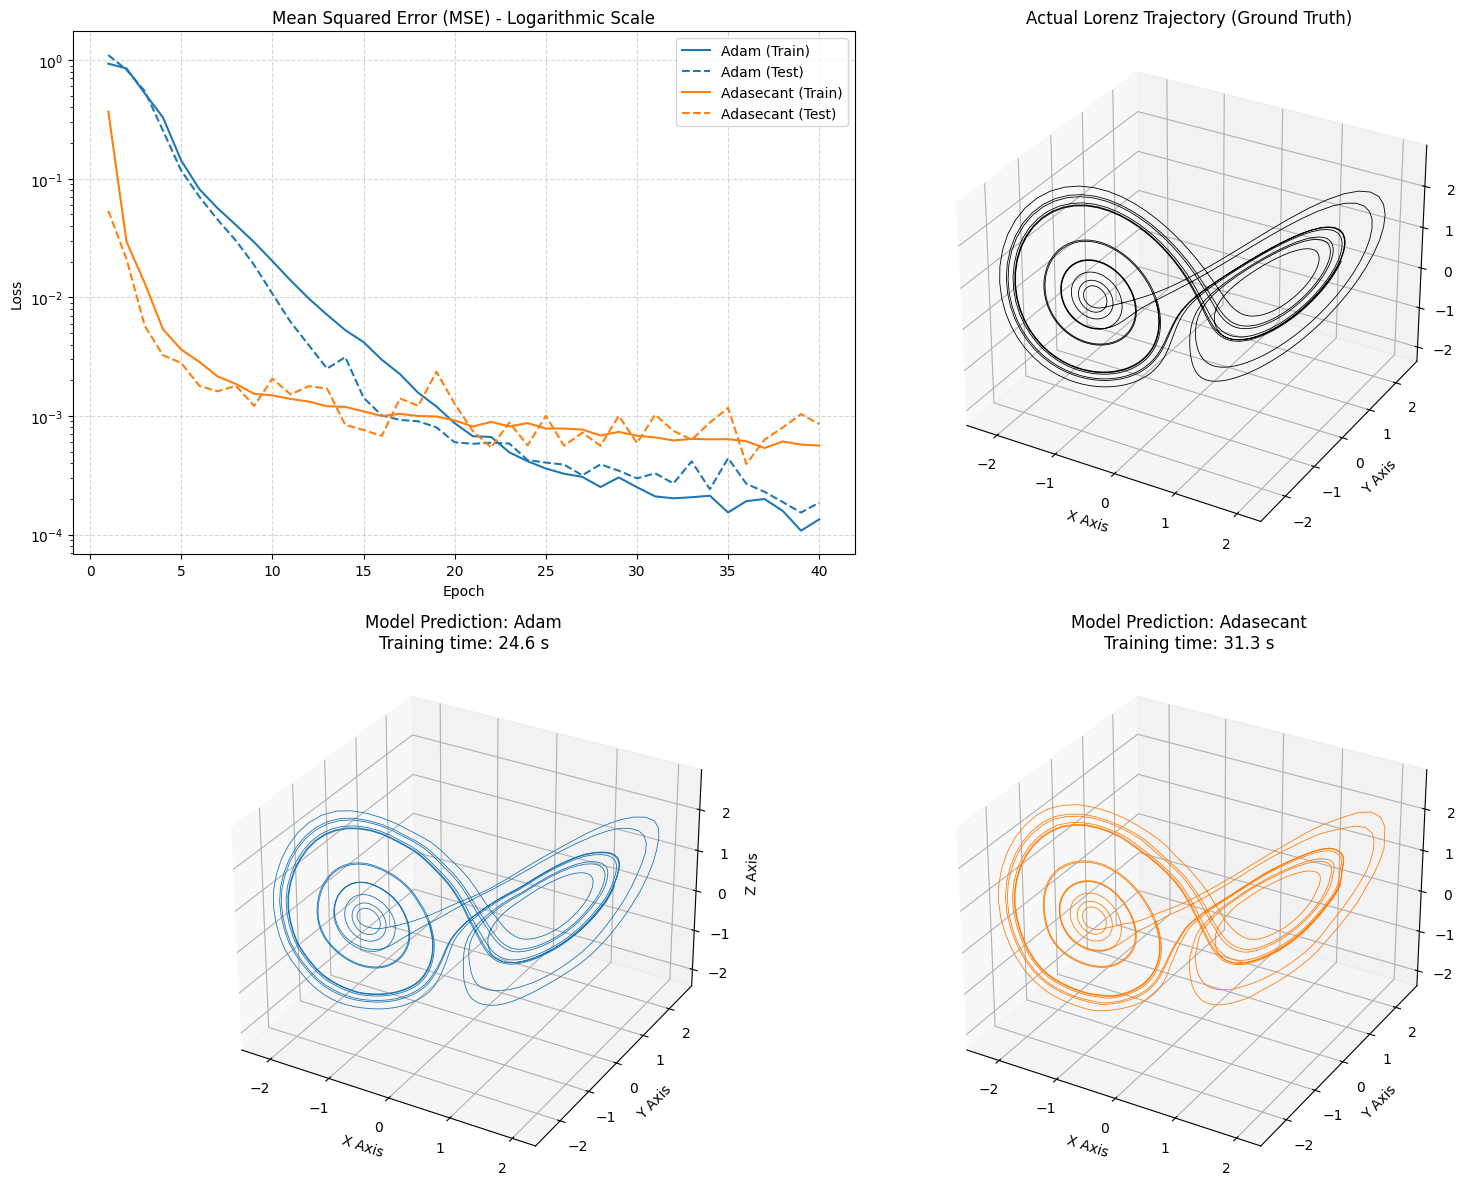

In [7]:
# ==========================================
# 1. DATA GENERATOR (Lorenz Attractor)
# ==========================================
def generate_lorenz(num_steps=5000, dt=0.01):
    """Solves Lorenz equations using the Euler method"""
    xs = np.empty(num_steps)
    ys = np.empty(num_steps)
    zs = np.empty(num_steps)
    
    # Initial conditions and parameters (standard for chaos)
    xs[0], ys[0], zs[0] = (0.0, 1.0, 1.05)
    sigma, rho, beta = 10.0, 28.0, 8.0 / 3.0

    for i in range(num_steps - 1):
        xs[i + 1] = xs[i] + (sigma * (ys[i] - xs[i])) * dt
        ys[i + 1] = ys[i] + (xs[i] * (rho - zs[i]) - ys[i]) * dt
        zs[i + 1] = zs[i] + (xs[i] * ys[i] - beta * zs[i]) * dt
        
    return np.vstack((xs, ys, zs)).T # Returns an array of shape [num_steps, 3]

# Generate and normalize data (Scaling is crucial for networks!)
print("Generating Lorenz Attractor...")
raw_data = generate_lorenz(num_steps=6000)
data_mean = raw_data.mean(axis=0)
data_std = raw_data.std(axis=0)
normalized_data = (raw_data - data_mean) / data_std

# ==========================================
# 2. DATASET FOR 3D SYSTEM
# ==========================================
class LorenzDataset(Dataset):
    def __init__(self, data, seq_length=20):
        self.X = []
        self.y = []
        for i in range(len(data) - seq_length):
            self.X.append(data[i : i + seq_length])
            self.y.append(data[i + seq_length]) # We predict the next point in 3D
            
        self.X = torch.tensor(self.X, dtype=torch.float32)
        self.y = torch.tensor(self.y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

SEQ_LENGTH = 50 
split_idx = 4500

train_dataset = LorenzDataset(normalized_data[:split_idx], seq_length=SEQ_LENGTH)
test_dataset = LorenzDataset(normalized_data[split_idx - SEQ_LENGTH:], seq_length=SEQ_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# ==========================================
# 3. DEEPER LSTM NETWORK (For a harder task)
# ==========================================
class DeepLSTM(nn.Module):
    def __init__(self, input_size=3, hidden_size=128, num_layers=3):
        super().__init__()
        # Note input=3 (X, Y, Z dimensions) and significantly more hidden neurons
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.0)
        
        # A few dense layers at the output for better feature interpretation
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, 3) # Output is a point in 3D (X, Y, Z)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :] 
        out = self.fc(out)
        return out


# ==========================================
# 4. TRAINING LOOP
# ==========================================
def run_lorenz_experiment(optimizer_name, device, train_loader, test_loader, epochs=40):
    print(f"\n--- Starting training (Lorenz 3D): {optimizer_name} ---")
    
    # Initialize the network defined in Step 3
    torch.manual_seed(42) 
    model = DeepLSTM(input_size=3, hidden_size=128, num_layers=3).to(device)
    loss_fn = nn.MSELoss() 
    
    if optimizer_name == "Adam":
        # Learning rate for Adam often requires tuning, 0.001 is a good start
        optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
    else:
        # Our custom Adasecant optimizer
        optimizer = Adasecant(model.parameters())

    history = {'train_loss': [], 'test_loss': [], 'time': 0, 'model': model}
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            
            pred = model(X)
            loss = loss_fn(pred, y)
            
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        avg_train_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)
        
        # Evaluation on test data (future)
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                pred = model(X)
                test_loss += loss_fn(pred, y).item()
                
        avg_test_loss = test_loss / len(test_loader)
        history['test_loss'].append(avg_test_loss)
        
        # Less aggressive console logging (every 5 epochs)
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:>2}/{epochs} | Loss Train: {avg_train_loss:.6f} | Loss Test: {avg_test_loss:.6f}")

    history['time'] = time.time() - start_time
    print(f"Completed in {history['time']:.2f} s.")
    return history

# ==========================================
# 5. MAIN PROGRAM LOOP AND 3D VISUALIZATION
# ==========================================
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
    print(f"Using device: {device}")

    # (Assuming train_loader and test_loader were created in section 2)
    NUM_EPOCHS = 40

    # Run the algorithms
    adam_results = run_lorenz_experiment("Adam", device, train_loader, test_loader, epochs=NUM_EPOCHS)
    adasecant_results = run_lorenz_experiment("Adasecant", device, train_loader, test_loader, epochs=NUM_EPOCHS)

    # --- PREPARING RESULTS FOR VISUALIZATION ---
    adam_model = adam_results['model'].eval()
    adasecant_model = adasecant_results['model'].eval()
    
    # Collect all data from test_loader into one large tensor to draw the full trajectory
    X_test_all, y_test_all = [], []
    for X, y in test_loader:
        X_test_all.append(X)
        y_test_all.append(y)
    
    X_test_all = torch.cat(X_test_all).to(device)
    y_test_all = torch.cat(y_test_all).cpu().numpy()

    # Calculate predictions for the entire test set at once
    with torch.no_grad():
        preds_adam = adam_model(X_test_all).cpu().numpy()
        preds_adasecant = adasecant_model(X_test_all).cpu().numpy()

    # --- DRAWING CHARTS (2x2 Grid) ---
    fig = plt.figure(figsize=(16, 12))

    # [Top-Left] Learning curves chart (Loss)
    ax1 = fig.add_subplot(2, 2, 1)
    epochs_range = range(1, NUM_EPOCHS + 1)
    ax1.plot(epochs_range, adam_results['train_loss'], label="Adam (Train)", color='tab:blue')
    ax1.plot(epochs_range, adam_results['test_loss'], label="Adam (Test)", color='tab:blue', linestyle='--')
    ax1.plot(epochs_range, adasecant_results['train_loss'], label="Adasecant (Train)", color='tab:orange')
    ax1.plot(epochs_range, adasecant_results['test_loss'], label="Adasecant (Test)", color='tab:orange', linestyle='--')
    
    ax1.set_yscale('log') # Logarithmic scale brings out differences when the error is close to 0
    ax1.set_title("Mean Squared Error (MSE) - Logarithmic Scale")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.5)

    # [Top-Right] True Attractor (Ground Truth)
    ax2 = fig.add_subplot(2, 2, 2, projection='3d')
    # Draw a line connecting X, Y, Z points
    ax2.plot(y_test_all[:, 0], y_test_all[:, 1], y_test_all[:, 2], color='black', linewidth=0.6)
    ax2.set_title("Actual Lorenz Trajectory (Ground Truth)")

    # [Bottom-Left] Adam algorithm prediction
    ax3 = fig.add_subplot(2, 2, 3, projection='3d')
    ax3.plot(preds_adam[:, 0], preds_adam[:, 1], preds_adam[:, 2], color='tab:blue', linewidth=0.6)
    ax3.set_title(f"Model Prediction: Adam\nTraining time: {adam_results['time']:.1f} s")

    # [Bottom-Right] Your Adasecant optimizer prediction
    ax4 = fig.add_subplot(2, 2, 4, projection='3d')
    ax4.plot(preds_adasecant[:, 0], preds_adasecant[:, 1], preds_adasecant[:, 2], color='tab:orange', linewidth=0.6)
    ax4.set_title(f"Model Prediction: Adasecant\nTraining time: {adasecant_results['time']:.1f} s")

    # Additional settings for consistent 3D axes appearance
    for ax in [ax2, ax3, ax4]:
        ax.set_xlabel('X Axis')
        ax.set_ylabel('Y Axis')
        ax.set_zlabel('Z Axis')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Variational AutoEncoder Test 

Device: cuda

--- VAE Training: Adam ---
Epoch 1/15 | Average loss: 190.1440
Epoch 2/15 | Average loss: 167.7190
Epoch 3/15 | Average loss: 163.7954
Epoch 4/15 | Average loss: 161.2962
Epoch 5/15 | Average loss: 159.4826
Epoch 6/15 | Average loss: 158.2773
Epoch 7/15 | Average loss: 157.1465
Epoch 8/15 | Average loss: 156.2204
Epoch 9/15 | Average loss: 155.4635
Epoch 10/15 | Average loss: 154.8169
Epoch 11/15 | Average loss: 154.1915
Epoch 12/15 | Average loss: 153.6584
Epoch 13/15 | Average loss: 153.2157
Epoch 14/15 | Average loss: 152.6781
Epoch 15/15 | Average loss: 152.2985

--- VAE Training: Adasecant ---
Epoch 1/15 | Average loss: 177.7248
Epoch 2/15 | Average loss: 167.2996
Epoch 3/15 | Average loss: 164.7118
Epoch 4/15 | Average loss: 163.0587
Epoch 5/15 | Average loss: 161.8383
Epoch 6/15 | Average loss: 160.9036
Epoch 7/15 | Average loss: 160.0860
Epoch 8/15 | Average loss: 159.3987
Epoch 9/15 | Average loss: 158.7643
Epoch 10/15 | Average loss: 158.2251
Epoch 11/15 | Avera

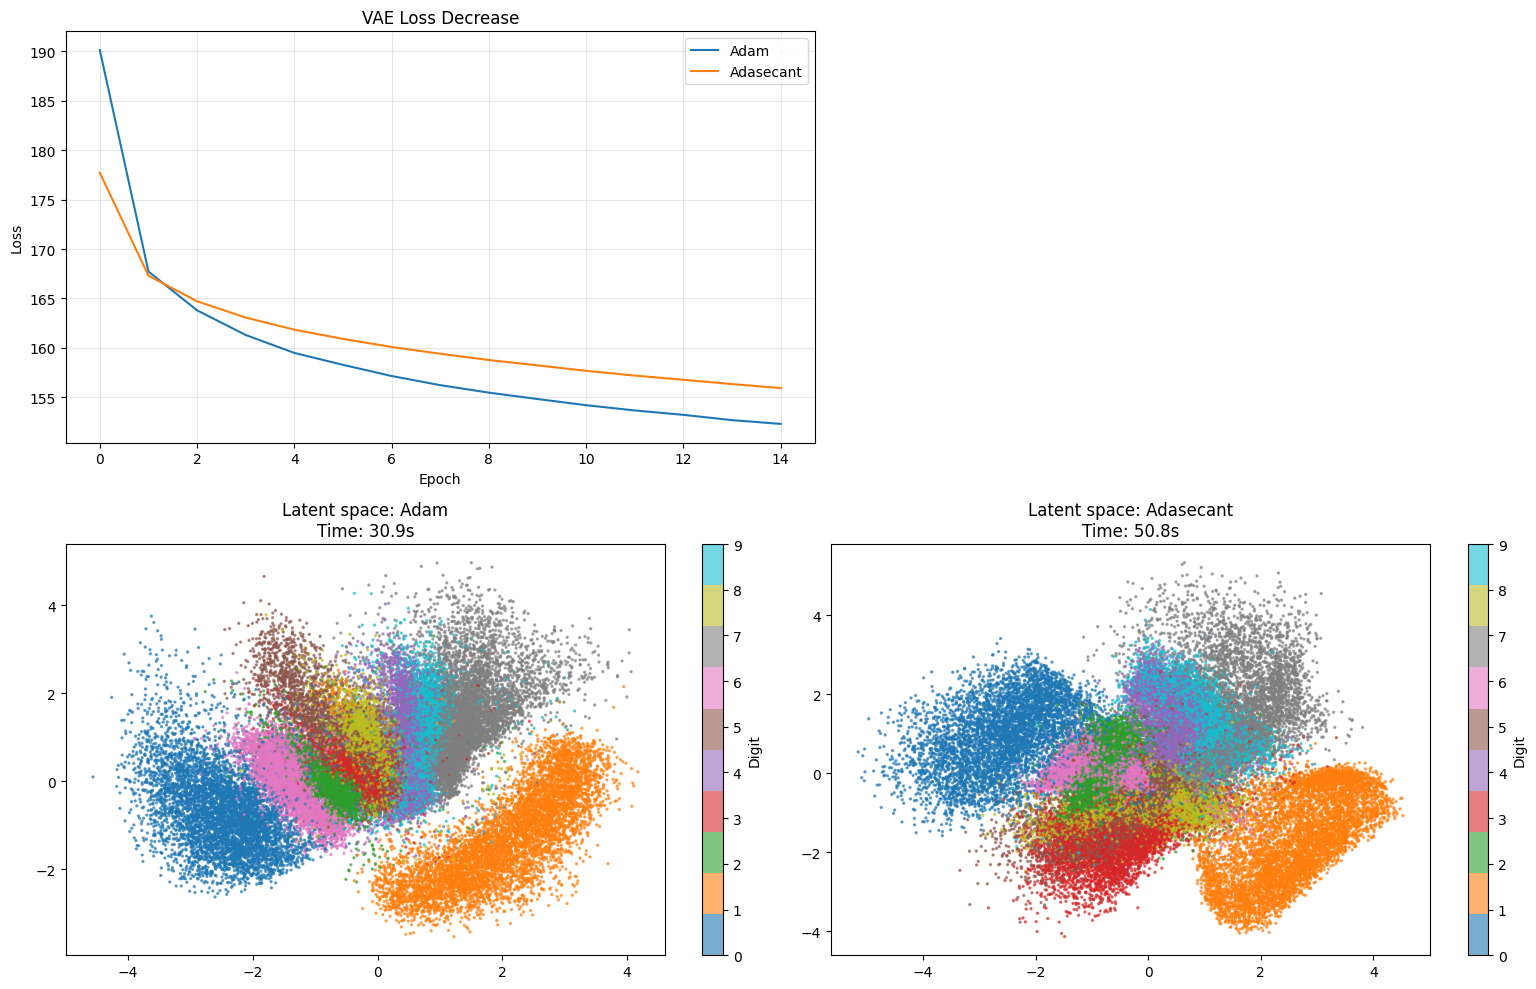

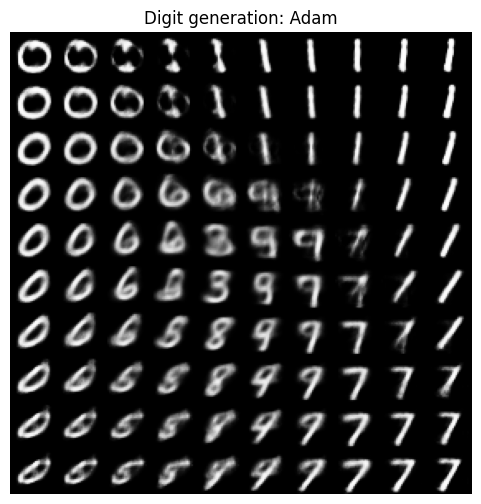

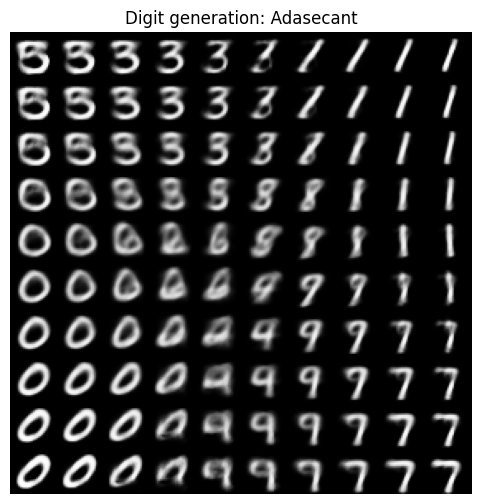

In [8]:
# ==========================================
# 1. VAE ARCHITECTURE
# ==========================================
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()
        
        # ENCODER: Image (28x28=784) -> Latent space
        self.fc1 = nn.Linear(784, 400)
        self.fc21 = nn.Linear(400, latent_dim) # mu (mean)
        self.fc22 = nn.Linear(400, latent_dim) # logvar (variance)
        
        # DECODER: Latent space -> Image
        self.fc3 = nn.Linear(latent_dim, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# VAE loss function: Reconstruction + KL Divergence
def vae_loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    # KL Divergence: we aim for the distribution to be close to N(0,1)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

# ==========================================
# 2. TRAINING FUNCTION
# ==========================================
def run_vae_experiment(optimizer_name, device, train_loader, epochs=15, latent_dim=2):
    print(f"\n--- VAE Training: {optimizer_name} ---")
    model = VAE(latent_dim=latent_dim).to(device)
    
    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    else:
        # Assuming Adasecant is available in the namespace
        optimizer = Adasecant(model.parameters())

    history = {'loss': [], 'time': 0, 'latent_points': [], 'labels': []}
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0
        for batch_idx, (data, labels) in enumerate(train_loader):
            data = data.to(device)
            optimizer.zero_grad()
            
            recon_batch, mu, logvar = model(data)
            loss = vae_loss_function(recon_batch, data, mu, logvar)
            
            loss.backward()
            train_loss += loss.item()
            optimizer.step()

            # Collect points from the latent space for visualization (last epoch only)
            if epoch == epochs:
                history['latent_points'].append(mu.detach().cpu().numpy())
                history['labels'].append(labels.numpy())

        avg_loss = train_loss / len(train_loader.dataset)
        history['loss'].append(avg_loss)
        print(f'Epoch {epoch}/{epochs} | Average loss: {avg_loss:.4f}')

    history['time'] = time.time() - start_time
    history['latent_points'] = np.concatenate(history['latent_points'])
    history['labels'] = np.concatenate(history['labels'])
    return history, model

# ==========================================
# 3. MAIN PART (MNIST + VISUALIZATION)
# ==========================================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    # Load MNIST
    train_loader = DataLoader(
        datasets.MNIST('./data', train=True, download=True, transform=transforms.ToTensor()),
        batch_size=128, shuffle=True)

    NUM_EPOCHS = 15
    LATENT_DIM = 2 # 2 dimensions to easily draw a 2D map

    adam_results, adam_model = run_vae_experiment("Adam", device, train_loader, epochs=NUM_EPOCHS)
    adasecant_results, adasecant_model = run_vae_experiment("Adasecant", device, train_loader, epochs=NUM_EPOCHS)

    # --- RESULTS VISUALIZATION ---
    plt.figure(figsize=(16, 10))

    # Chart 1: Loss comparison
    plt.subplot(2, 2, 1)
    plt.plot(adam_results['loss'], label='Adam')
    plt.plot(adasecant_results['loss'], label='Adasecant')
    plt.title("VAE Loss Decrease")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Chart 2: Latent Space - ADAM
    plt.subplot(2, 2, 3)
    plt.scatter(adam_results['latent_points'][:, 0], adam_results['latent_points'][:, 1], 
                c=adam_results['labels'], cmap='tab10', s=2, alpha=0.6)
    plt.colorbar(label='Digit')
    plt.title(f"Latent space: Adam\nTime: {adam_results['time']:.1f}s")

    # Chart 3: Latent Space - ADASECANT
    plt.subplot(2, 2, 4)
    plt.scatter(adasecant_results['latent_points'][:, 0], adasecant_results['latent_points'][:, 1], 
                c=adasecant_results['labels'], cmap='tab10', s=2, alpha=0.6)
    plt.colorbar(label='Digit')
    plt.title(f"Latent space: Adasecant\nTime: {adasecant_results['time']:.1f}s")

    plt.tight_layout()
    plt.show()

    # Display reconstructions
    def plot_reconstructions(model, device, title):
        model.eval()
        with torch.no_grad():
            # Generate images from a grid of points in the latent space
            n = 10
            digit_size = 28
            figure = np.zeros((digit_size * n, digit_size * n))
            grid_x = np.linspace(-3, 3, n)
            grid_y = np.linspace(-3, 3, n)

            for i, yi in enumerate(grid_x):
                for j, xi in enumerate(grid_y):
                    z_sample = torch.tensor([[xi, yi]], dtype=torch.float).to(device)
                    x_decoded = model.decode(z_sample)
                    digit = x_decoded[0].reshape(digit_size, digit_size).cpu().numpy()
                    figure[i * digit_size: (i + 1) * digit_size,
                           j * digit_size: (j + 1) * digit_size] = digit

            plt.figure(figsize=(6, 6))
            plt.imshow(figure, cmap='Greys_r')
            plt.title(title)
            plt.axis('off')
            plt.show()

    plot_reconstructions(adam_model, device, "Digit generation: Adam")
    plot_reconstructions(adasecant_model, device, "Digit generation: Adasecant")

# Transfer learning 

Compute device: cuda

--- Flowers102 Training: Adam ---
Epoch  1/50 | Loss (Train): 4.5120 | Accuracy (Test): 19.17%
Epoch  5/50 | Loss (Train): 1.9667 | Accuracy (Test): 75.88%
Epoch 10/50 | Loss (Train): 0.8641 | Accuracy (Test): 85.82%
Epoch 15/50 | Loss (Train): 0.5185 | Accuracy (Test): 89.28%
Epoch 20/50 | Loss (Train): 0.2848 | Accuracy (Test): 90.01%
Epoch 25/50 | Loss (Train): 0.2194 | Accuracy (Test): 90.67%
Epoch 30/50 | Loss (Train): 0.1774 | Accuracy (Test): 90.50%
Epoch 35/50 | Loss (Train): 0.1569 | Accuracy (Test): 91.15%
Epoch 40/50 | Loss (Train): 0.1492 | Accuracy (Test): 90.88%
Epoch 45/50 | Loss (Train): 0.1092 | Accuracy (Test): 90.60%
Epoch 50/50 | Loss (Train): 0.0893 | Accuracy (Test): 90.91%
Completed in 283.9 s.

--- Flowers102 Training: Adasecant ---
Epoch  1/50 | Loss (Train): 3.8588 | Accuracy (Test): 53.08%
Epoch  5/50 | Loss (Train): 0.3645 | Accuracy (Test): 84.16%
Epoch 10/50 | Loss (Train): 0.1555 | Accuracy (Test): 86.92%
Epoch 15/50 | Loss (Train): 

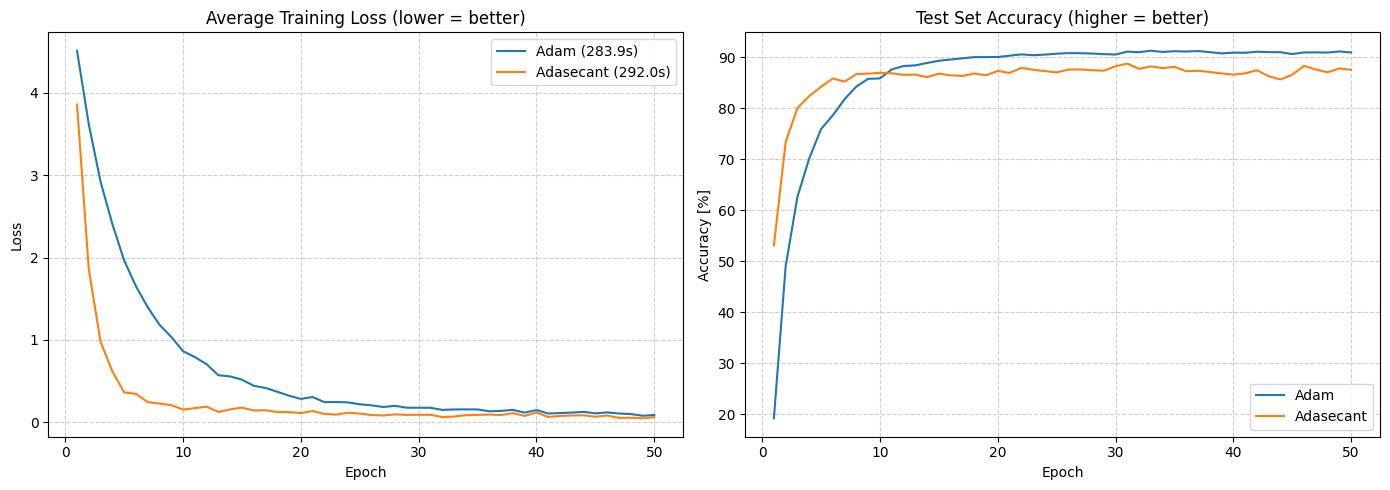

In [11]:
# ==========================================
# 1. MODEL PREPARATION (Transfer Learning)
# ==========================================
def get_finetune_model(num_classes=102):
    # Download ResNet-18 weights pre-trained on ImageNet
    model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    
    # STEP 1: Freeze all layers
    for param in model.parameters():
        param.requires_grad = False
        
    # STEP 2: Unfreeze only the last block (layer4)
    for param in model.layer4.parameters():
        param.requires_grad = True
        
    # STEP 3: Replace the classification layer from 1000 to 102 classes (flowers)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    
    return model

# ==========================================
# 2. TRAINING FUNCTION
# ==========================================
def run_flowers_experiment(optimizer_name, device, train_loader, test_loader, epochs=50):
    print(f"\n--- Flowers102 Training: {optimizer_name} ---")
    
    torch.manual_seed(42)
    model = get_finetune_model(num_classes=102).to(device)
    loss_fn = nn.CrossEntropyLoss()
    
    # Pass only the unfrozen weights to the optimizer (layer4 + fc)
    active_parameters = filter(lambda p: p.requires_grad, model.parameters())
    
    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(active_parameters, lr=1e-4) 
    else:
        # Your algorithm: Adasecant
        optimizer = Adasecant(active_parameters) 

    history = {'train_loss': [], 'test_acc': [], 'time': 0}
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        # --- TRAINING ---
        model.train()
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        avg_train_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)
        
        # --- EVALUATION (on a massive test set) ---
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        test_acc = 100 * correct / total
        history['test_acc'].append(test_acc)
        
        # Log every 5 epochs to avoid spamming the console
        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:>2}/{epochs} | Loss (Train): {avg_train_loss:.4f} | Accuracy (Test): {test_acc:.2f}%")

    history['time'] = time.time() - start_time
    print(f"Completed in {history['time']:.1f} s.")
    return history

# ==========================================
# 3. MAIN PROGRAM LOOP AND VISUALIZATION
# ==========================================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Compute device: {device}")

    # Standard transformations forcing generalization (especially important for small datasets!)
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    test_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    print("Downloading and preparing the Flowers102 dataset...")
    # NOTE: In the Flowers102 dataset, we use the `split` argument instead of `train`
    train_dataset = datasets.Flowers102(root='./data', split='train', download=True, transform=train_transform)
    test_dataset = datasets.Flowers102(root='./data', split='test', download=True, transform=test_transform)

    # Due to the small training set (1020 images), batch_size=32 or 64 is a good balance
    batch_size = 64
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    # Run the experiment for a long distance
    NUM_EPOCHS = 50 

    adam_results = run_flowers_experiment("Adam", device, train_loader, test_loader, epochs=NUM_EPOCHS)
    adasecant_results = run_flowers_experiment("Adasecant", device, train_loader, test_loader, epochs=NUM_EPOCHS)

    # --- DRAWING CHARTS ---
    epochs_range = range(1, NUM_EPOCHS + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss Chart
    ax1.plot(epochs_range, adam_results['train_loss'], label=f"Adam ({adam_results['time']:.1f}s)", color='tab:blue')
    ax1.plot(epochs_range, adasecant_results['train_loss'], label=f"Adasecant ({adasecant_results['time']:.1f}s)", color='tab:orange')
    ax1.set_title("Average Training Loss (lower = better)")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Accuracy Chart
    ax2.plot(epochs_range, adam_results['test_acc'], label="Adam", color='tab:blue')
    ax2.plot(epochs_range, adasecant_results['test_acc'], label="Adasecant", color='tab:orange')
    ax2.set_title("Test Set Accuracy (higher = better)")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy [%]")
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()